In [2]:
import sys

assert sys.version_info >= (3, 10)

In [3]:
from packaging.version import Version
import torch

assert Version(torch.__version__) >= Version("2.6.0")

In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

In [5]:
import matplotlib.pyplot as plt

plt.rc("font", size=14)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)

In [6]:
import deepxde as dde
import numpy as np

torch.manual_seed(42)
torch.cuda.manual_seed(42)

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting up the backend

In [7]:
dde.config.set_default_float("float64")
print(f"Backend: {dde.backend.backend_name}")

Set the default float type to float64
Backend: pytorch


Defining Exact solution

In [8]:
def exact_solution(x):
    return (x + 1) ** 2

Defing a domain Geometry with a boudary of -1 and 1

In [9]:
geom = dde.geometry.Interval(-1, 1)


Defining the Partial Differential Equation here second order so hessian

In [10]:
def pde(x, y):
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_xx

creating a left boundary condition

In [11]:
def boundary_left(x, on_boundary):
    return on_boundary and np.isclose(x[0], -1)

bc_left = dde.icbc.DirichletBC(geom, lambda x: 0, boundary_left)

Creating a right boundary condition

In [12]:
def boundary_right(x, on_boundary):
    return on_boundary and np.isclose(x[0], 1)

bc_right = dde.icbc.NeumannBC(geom, lambda x: 4, boundary_right)

Generating the data using Numpy

In [13]:
observe_x = np.linspace(-1, 1, 35).reshape(-1, 1)
observe_y  = exact_solution(observe_x)
noise  = 0.1 * np.random.randn(35, 1)
observe_y = observe_y + noise
observe = dde.icbc.PointSetBC(observe_x, observe_y, component=0)

Combining all the Data

In [14]:
data  = dde.data.PDE(
    geom, pde,
    [bc_left, bc_right, observe],
    num_domain=3000,
    num_boundary=200,
    num_test=500
)

Building a Neural Network

In [15]:
net  = dde.nn.FNN([1, 256, 128, 64, 1], "tanh", "Glorot uniform")
model = dde.Model(data, net)

Creating a class for generating Self Adaptive Weights through a Callback function during training

In [16]:
class SoftmaxAdaptiveWeights(dde.callbacks.Callback):
    def __init__(self, model, every_n_epochs=100, alpha_0=1.0, gamma=0.999):
        super().__init__()
        self.model = model
        self.every_n_epochs = every_n_epochs
        self.alpha = alpha_0
        self.gamma= gamma
        self.epoch =0

    def on_epoch_end(self):
        self.epoch += 1
        if self.epoch % self.every_n_epochs != 0:
            return

        if len(self.model.losshistory.loss_train) ==0:
            return
        current_losses = self.model.losshistory.loss_train[-1]
        exp_terms = np.exp(self.alpha * np.array(current_losses))
        new_weights = exp_terms / np.sum(exp_terms)
        self.alpha *= self.gamma
        self.model.loss_weights = new_weights.tolist()
        print(f"Epoch {self.epoch}: Adaptive weights updated to {new_weights.tolist()}, alpha decayed to {self.alpha:.4f}")

adaptive_callback = SoftmaxAdaptiveWeights(model, every_n_epochs = 20)

Training the MOdel with 2 stage optimization
1. Adam Optimizer
2. L-BFGS

In [17]:
print("\nStage 1: Adam Optimizer")
model.compile("adam", lr = 0.01,
              loss_weights=[1.0] * 4,
              decay=("inverse time", 1000, 0.1))

losshistory, train_state = model.train(iterations=2000, display_every=200, callbacks=[adaptive_callback])
dde.optimizers.config.set_LBFGS_options(maxiter=200)
model.compile("L-BFGS", loss_weights=model.loss_weights)
losshistory, train_state = model.train(display_every=50,callbacks=[adaptive_callback])


Stage 1: Adam Optimizer
Compiling model...
'compile' took 2.115228 s

Training model...



/home/ziaur/ziazh/lib/python3.14/site-packages/torch/autograd/graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:370.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Step      Train loss                                  Test loss                                   Test metric
0         [9.35e-05, 5.97e-03, 1.54e+01, 3.15e+00]    [8.44e-05, 5.97e-03, 1.54e+01, 3.15e+00]    []  
Epoch 20: Adaptive weights updated to [1.9905546785448573e-07, 2.0022769669151385e-07, 0.9999949480209103, 4.652695925166855e-06], alpha decayed to 0.9990
Epoch 40: Adaptive weights updated to [2.0215063400738456e-07, 2.0333989618980948e-07, 0.9999948843356328, 4.710173837169851e-06], alpha decayed to 0.9980
Epoch 60: Adaptive weights updated to [2.052907599711104e-07, 2.064972843921712e-07, 0.9999948199086921, 4.7683032634447866e-06], alpha decayed to 0.9970
Epoch 80: Adaptive weights updated to [2.0847644968939186e-07, 2.0970046804711773e-07, 0.9999947547322149, 4.827090867401436e-06], alpha decayed to 0.9960
Epoch 100: Adaptive weights updated to [2.1170831450340646e-07, 2.1295006133130658e-07, 0.9999946887982518, 4.886543372377983e-06], alpha decayed to 0.9950
Epoch 120: A

Evaluating the results using Metrics

Create the test points using Numpy

In [18]:
x_test =  np.linspace(-1, 1, 15).reshape(-1, 1)
y_exact = exact_solution(x_test)
y_pred = model.predict(x_test)
noise = 0.1 * np.random.randn(15, 1)
y_test = y_exact + noise


Calculating the performance Metrices

In [19]:
absolute_error = np.abs(y_test  - y_pred)
relative_error = absolute_error / (np.abs(y_test) + 1e-10)
l2_error = np.linalg.norm(y_test - y_pred) / np.linalg.norm(y_test)

u_at_minus1 = model.predict(np.array([[-1.0]]))[0, 0]
u_at_plus1 = model.predict(np.array([[1.0]]))[0, 0]

x_right = np.array([[1.0]])
du_dx_at_1 = model.predict(
    x_right,
    operator=lambda x, y: dde.grad.jacobian(y, x, i=0,j=0)
)[0, 0]

print("📊 PERFORMANCE METRICS")
print(f"L2 Relative Error:      {l2_error:.6f}")
print(f"Max Absolute Error:     {np.max(absolute_error):.6f}")
print(f"Mean Absolute Error:    {np.mean(absolute_error):.6f}")

print("\n📍 BOUNDARY CONDITION CHECK")
print(f"u(-1) = {u_at_minus1:.6f}  (Target: 0.0)")
print(f"du/dx(1) = {du_dx_at_1:.6f}  (Target: 4.0)")



📊 PERFORMANCE METRICS
L2 Relative Error:      0.258157
Max Absolute Error:     0.754548
Mean Absolute Error:    0.441414

📍 BOUNDARY CONDITION CHECK
u(-1) = -0.450777  (Target: 0.0)
du/dx(1) = 3.403224  (Target: 4.0)


Extract the Individual Losses

DeepXDE already computes the exact losses used during training



In [21]:
final_train_losses = model.losshistory.loss_train[-1]
L_pde, L_bc_l, L_bc_r, L_data = final_train_losses
print("Final training losses (Unweighted - REAL values used by DeepXDE)")
print(f"L_PDE       : {L_pde:.6e}")
print(f"L_BC_left   : {L_bc_l:.6e}")
print(f"L_BC_Right  : {L_bc_r: .6e}")
print(f"L_data      : {L_data: .6e}")
current_weights = model.loss_weights  
weighted = [w * l for w, l in zip(current_weights, final_train_losses)]
print(f"λ_PDE  × L_PDE      : {weighted[0]:.6e}")
print(f"λ_BC_l × L_BC_left  : {weighted[1]:.6e}")
print(f"λ_BC_r × L_BC_right : {weighted[2]:.6e}")
print(f"λ_data × L_data     : {weighted[3]:.6e}")
print(f"\nTotal Weighted Loss : {sum(weighted):.6e}")
print("="*60)

Final training losses (Unweighted - REAL values used by DeepXDE)
L_PDE       : 1.703375e-01
L_BC_left   : 4.920446e-02
L_BC_Right  :  8.670266e-02
L_data      :  7.474413e-02
λ_PDE  × L_PDE      : 4.618007e-02
λ_BC_l × L_BC_left  : 1.191475e-02
λ_BC_r × L_BC_right : 2.110773e-02
λ_data × L_data     : 1.818475e-02

Total Weighted Loss : 9.738729e-02


Visualisation

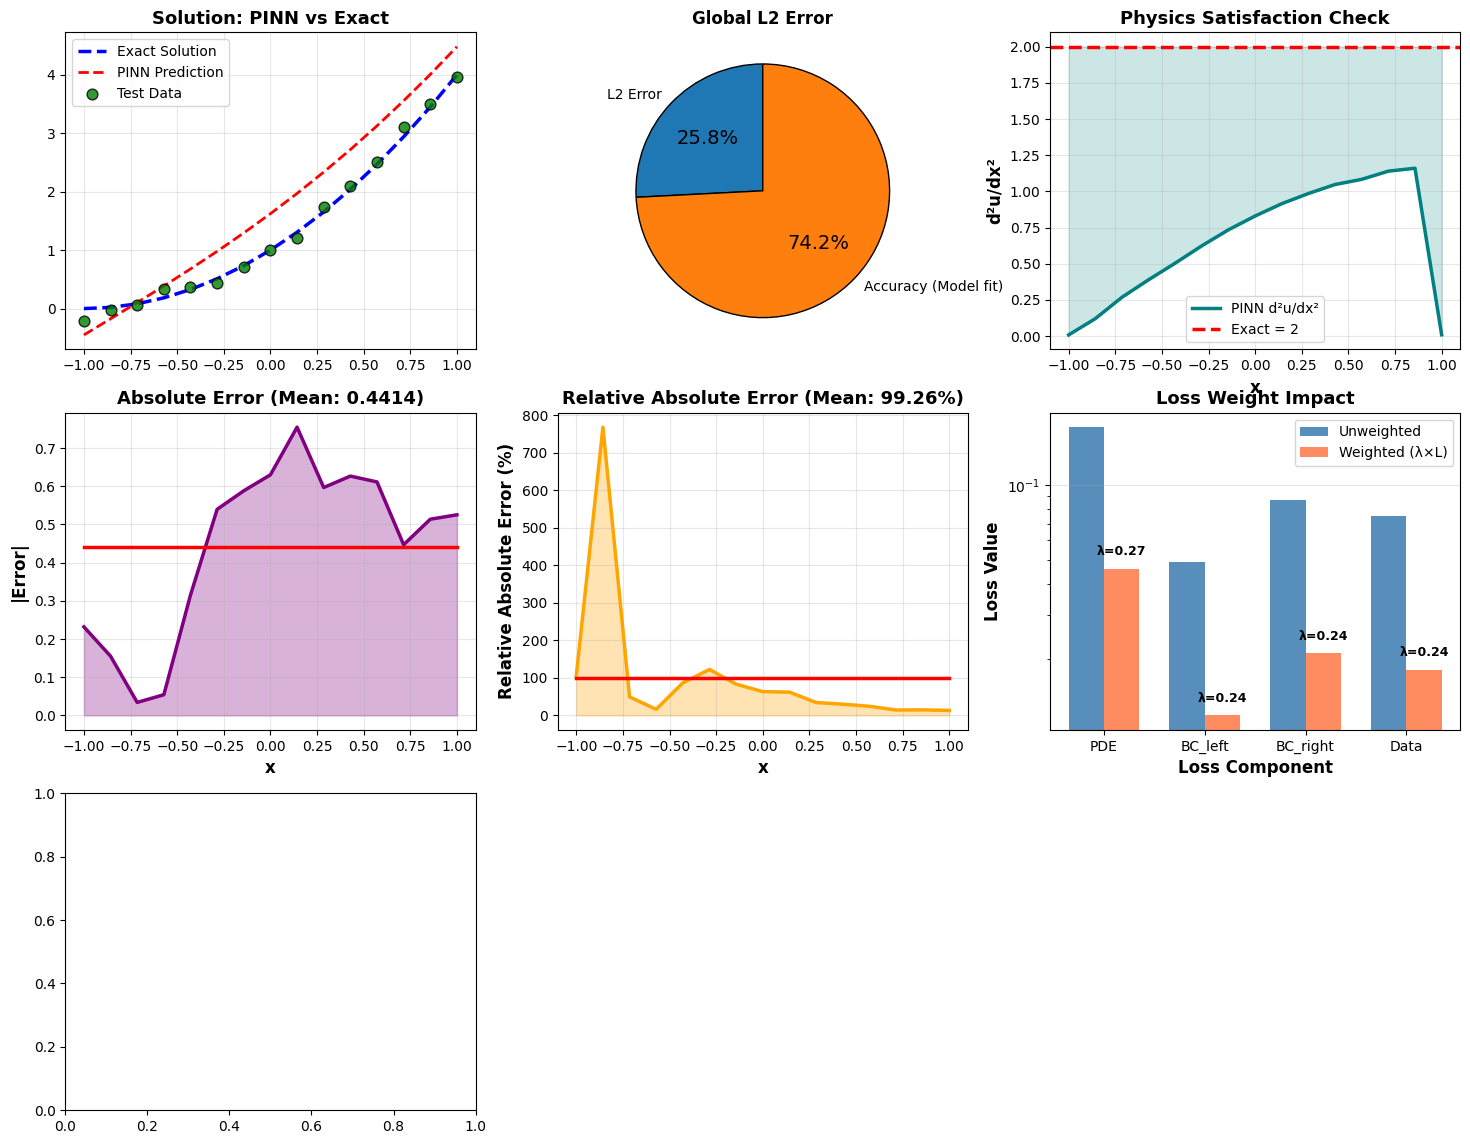

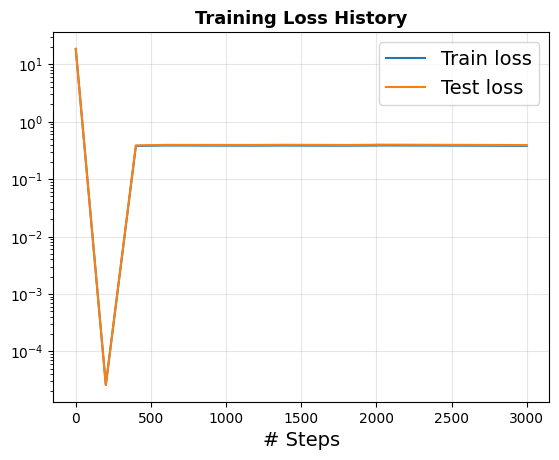

In [31]:
fig = plt.figure(figsize=(18, 14))

ax1 = plt.subplot(3, 3, 1)
plt.plot(x_test, y_exact, "b--", linewidth=2.5, label='Exact Solution')
plt.plot(x_test, y_pred, 'r--', linewidth=2, label="PINN Prediction")
plt.scatter(x_test, y_test, c='green', s=60,
            label='Test Data', zorder=5, alpha=0.8, edgecolors='black')
plt.title("Solution: PINN vs Exact", fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

ax2 = plt.subplot(3,3,2)
l2_error_pct = 100 * np.linalg.norm(y_test - y_pred) / np.linalg.norm(y_test)
sizes = [l2_error_pct, 100 - l2_error_pct]
labels = [f'L2 Error', 'Accuracy (Model fit)']
ax2.pie(sizes, labels=labels, autopct='%1.1f%%',
        startangle=90, wedgeprops={'linewidth': 1, 'edgecolor': 'black'})
ax2.set_title('Global L2 Error', fontsize=12, fontweight='bold')
ax2.set_aspect('equal')

ax3 = plt.subplot(3, 3, 3)
d2u_dx2 = model.predict(
    x_test,
    operator=lambda x, y: dde.grad.hessian(y, x, i=0, j=0)
)
plt.plot(x_test, d2u_dx2, 'teal', linewidth=2.5, label='PINN d²u/dx²')
plt.axhline(y=2, color='red', linestyle='--', linewidth=2.5, label='Exact = 2')
plt.fill_between(x_test.flatten(), 2, d2u_dx2.flatten(), alpha=0.2, color='teal')
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('d²u/dx²', fontsize=12, fontweight='bold')
plt.title('Physics Satisfaction Check', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

ax4 = plt.subplot(3, 3, 4)

# Absolute error curve
plt.plot(x_test, absolute_error, color='purple', linewidth=2.5)

# Mean absolute error line (constant horizontal line)
mean_abs_err = np.mean(absolute_error)
plt.plot(x_test, np.full_like(x_test, mean_abs_err), color='red', linewidth=2.5)

# Shaded area
plt.fill_between(x_test.flatten(), 0, absolute_error.flatten(), alpha=0.3, color='purple')

# Labels and formatting
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('|Error|', fontsize=12, fontweight='bold')
plt.title(f'Absolute Error (Mean: {np.mean(absolute_error):.4f})',
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

ax5 = plt.subplot(3, 3, 5)

# Relative absolute error curve (%)
plt.plot(x_test, relative_error * 100, color='orange', linewidth=2.5)

# Mean relative error line (horizontal)
mean_rel_err_pct = np.mean(relative_error) * 100
plt.plot(x_test, np.full_like(x_test, mean_rel_err_pct), color='red', linewidth=2.5)

# Shaded area
plt.fill_between(x_test.flatten(), 0, (relative_error * 100).flatten(),
                 alpha=0.3, color='orange')

# Labels and formatting
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('Relative Absolute Error (%)', fontsize=12, fontweight='bold')
plt.title(f'Relative Absolute Error (Mean: {mean_rel_err_pct:.2f}%)',
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

ax6 = plt.subplot(3, 3, 6)
# Use actual final training losses from DeepXDE
losses = model.losshistory.loss_train[-1]          # [PDE, BC_left, BC_right, Data]
# FIXED: Access dynamic weights from model attribute
current_weights = model.loss_weights
weighted = [w * l for w, l in zip(current_weights, losses)]
components = ['PDE', 'BC_left', 'BC_right', 'Data']
x_pos = np.arange(len(components))
width = 0.35
ax6.bar(x_pos - width/2, losses,    width, label='Unweighted', alpha=0.9, color='steelblue')
ax6.bar(x_pos + width/2, weighted,  width, label='Weighted (λ×L)', alpha=0.9, color='coral')
ax6.set_xlabel('Loss Component', fontsize=12, fontweight='bold')
ax6.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
ax6.set_title('Loss Weight Impact', fontsize=13, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(components)
ax6.set_yscale('log')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')
# FIXED: Use current_weights for annotations
for bar, λ in zip(ax6.patches[len(components):], current_weights):
    h = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2, h * 1.1, f'λ={λ:.2f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax7 = plt.subplot(3, 3, 7)
dde.utils.plot_loss_history(losshistory)
plt.title('Training Loss History', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.show()

In [34]:
test_points = 15
# Helper for perfect alignment
def fmt(label, value, width_label=45, width_value=12):
    return f"{label:<{width_label}} : {value:>{width_value}}"


print("\n" + "=" * 70)
print("📋 FINAL SUMMARY".center(70))
print("=" * 70)



# ------------------------------------------------------------
# Training Points Summary
# ------------------------------------------------------------
print("\n" + "═" * 70)
print("TRAINING POINTS CONFIGURATION".center(70))
print("═" * 70)

print(fmt("Physics collocation points (num_domain)", data.num_domain))
print(fmt("Boundary points (num_boundary)", data.num_boundary))
print(fmt("Total training points used", data.train_x_all.shape[0]))
print("-" * 70)
print(fmt("Experimental/FEA train data points (PointSetBC)", len(observe_x)))
print("-" * 70)
print(fmt("Test/evaluation points (num_test)", data.num_test))
print("═" * 70)



# ------------------------------------------------------------
# Neural Network Architecture
# ------------------------------------------------------------
print("\nNEURAL NETWORK ARCHITECTURE")
print("-" * 70)
print(net)
print("-" * 70)



# ------------------------------------------------------------
# Best Model Performance Summary (Lowest Test Loss)
# ------------------------------------------------------------
best_step = np.argmin([sum(l) for l in model.losshistory.loss_test])
best_train = model.losshistory.loss_train[best_step]
best_test  = model.losshistory.loss_test[best_step]

total_train = sum(best_train)
total_test  = sum(best_test)

print("\n" + "═" * 70)
print("BEST MODEL PERFORMANCE (Lowest Total Test Loss)".center(70))
print("═" * 70)

print(fmt("Best training step/iteration", best_step))
print("-" * 70)
print(fmt("Total weighted training loss", f"{total_train:.6e}"))
print("-" * 70)

print(fmt("Train → PDE loss",      f"{best_train[0]:.6e}"))
print(fmt("Train → BC_left loss",   f"{best_train[1]:.6e}"))
print(fmt("Train → BC_right loss",  f"{best_train[2]:.6e}"))
print(fmt("Train → Data loss",      f"{best_train[3]:.6e}"))

print("-" * 70)

print(fmt("Total weighted test loss", f"{total_test:.6e}"))
print("-" * 70)
print(fmt("Test → PDE loss",       f"{best_test[0]:.6e}"))
print(fmt("Test → BC_left loss",    f"{best_test[1]:.6e}"))
print(fmt("Test → BC_right loss",   f"{best_test[2]:.6e}"))
print(fmt("Test → Data loss",       f"{best_test[3]:.6e}"))
print("═" * 70)



# ------------------------------------------------------------
# Test Points Summary
# ------------------------------------------------------------
print("\n🔧 Experimental/FEA Test Data Points for Model Evaluation")
print("-" * 70)
print(fmt("Experimental/FEA test data points", test_points))



# ------------------------------------------------------------
# Final Individual Losses
# ------------------------------------------------------------
losses = model.losshistory.loss_train[-1]
print("\n" + "═" * 70)
print("FINAL TRAINING LOSSES (Last Iteration)".center(70))
print("═" * 70)
print(f"{'Component':<15} {'Unweighted':>15} {'Weighted (λ×L)':>20} {'λ':>8}")
print("-" * 70)
components = ["PDE", "BC_left", "BC_right", "Data"]
# FIXED: Access dynamic weights
current_weights = model.loss_weights
for i, comp in enumerate(components):
    L = losses[i]
    w = current_weights[i]  # FIXED: Use current_weights
    print(f"{comp:<15} {L:>15.6e} {w*L:>20.6e} {w:>8.2f}")  # Added .2f for λ readability
print("-" * 70)
total_loss = sum(w * l for w, l in zip(current_weights, losses))  # FIXED: Use current_weights
print(f"{'TOTAL WEIGHTED LOSS':<35}{total_loss:>20.6e}")
print("═" * 70)



# ------------------------------------------------------------
# Metrics Summary
# ------------------------------------------------------------
print("\n📊 METRICS")
print("-" * 70)
print(f"{'Metric':<30} {'Value':>15} {'Target'}")
print("-" * 70)

print(f"{'L2 Relative Error':<30} {l2_error:>15.6f} < 0.05 (excellent)")
print(f"{'Mean Absolute Error':<30} {np.mean(absolute_error):>15.6f} < 0.10")
print(f"{'Max Absolute Error':<30} {np.max(absolute_error):>15.6f} < 0.20")
print(f"{'Mean Relative Error':<30} {np.mean(relative_error):>15.6f} < 0.20")

print("\n")
print(f"{'u(-1) [should be 0]':<30} {u_at_minus1:>15.6f} 0.0")
print(f"{'u(1) [should be 4]':<30} {u_at_plus1:>15.6f} 4.0")
print(f"{'du/dx(1) [should be 4]':<30} {du_dx_at_1:>15.6f} 4.0")

pde_res_mean = np.mean(np.abs(d2u_dx2 - 2))
print(f"{'PDE Residual (mean abs)':<30} {pde_res_mean:>15.6f} < 0.1")

print("=" * 70)


                           📋 FINAL SUMMARY                            

══════════════════════════════════════════════════════════════════════
                    TRAINING POINTS CONFIGURATION                     
══════════════════════════════════════════════════════════════════════
Physics collocation points (num_domain)       :         3000
Boundary points (num_boundary)                :          200
Total training points used                    :         3200
----------------------------------------------------------------------
Experimental/FEA train data points (PointSetBC) :           35
----------------------------------------------------------------------
Test/evaluation points (num_test)             :          500
══════════════════════════════════════════════════════════════════════

NEURAL NETWORK ARCHITECTURE
----------------------------------------------------------------------
FNN(
  (linears): ModuleList(
    (0): Linear(in_features=1, out_features=256, bias=True)
    

In [35]:
model.save("pinn_poisson_model")
print("\n💾 Model saved to 'pinn_poisson_model/'")

# Save configuration
config = {
    'loss_weights': model.loss_weights,
    'architecture': [1, 256, 128, 64, 1],
    'activation': 'tanh',
    'l2_error': l2_error,
    'training_iterations': 5000
}

import json
with open('pinn_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print("💾 Configuration saved to 'pinn_config.json'")

print("\n✅ PINN TRAINING COMPLETE WITH LOSS WEIGHT CONTROL!")


💾 Model saved to 'pinn_poisson_model/'
💾 Configuration saved to 'pinn_config.json'

✅ PINN TRAINING COMPLETE WITH LOSS WEIGHT CONTROL!
